# 03 — Détection de communautés et interprétation biologique

**Objectif de ce notebook :**
1. Détecter des sous-groupes ("communautés") de cytokines fortement interconnectées avec l'algorithme de Louvain
2. Visualiser le réseau coloré par communauté
3. Interpréter chaque communauté à l'aide des annotations UniProt et de l'enrichissement fonctionnel STRING
4. Comparer les communautés détectées aux familles fonctionnelles connues (Th1 / Th2 / Th17 / régulatrices / chimiokines)

**Données utilisées :**
- `data/raw/string_network.csv` — le réseau d'interactions (seuil de confiance 700)
- `data/raw/uniprot_annotations.csv` — annotations biologiques
- `data/raw/string_enrichment.csv` — enrichissement fonctionnel global
- `data/processed/centrality_scores.csv` — scores de centralité calculés dans le notebook 02

## 1. Imports et chargement des données

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

network_df = pd.read_csv("../data/raw/string_network.csv")
annotations_df = pd.read_csv("../data/raw/uniprot_annotations.csv")
centrality_df = pd.read_csv("../data/processed/centrality_scores.csv")

G = nx.from_pandas_edgelist(
    network_df,
    source="preferredName_A",
    target="preferredName_B",
    edge_attr="score",
    create_using=nx.Graph()
)

print(f"Graphe chargé : {G.number_of_nodes()} nœuds, {G.number_of_edges()} arêtes")

Graphe chargé : 21 nœuds, 147 arêtes


## 2. Détection de communautés avec l'algorithme de Louvain

**Rappel du principe :** Louvain cherche le découpage du réseau en groupes qui **maximise la modularité** —
c'est-à-dire un découpage où il y a beaucoup de connexions à l'intérieur de chaque groupe et peu entre les groupes.

**Le paramètre `resolution` :** contrôle la taille des communautés trouvées.
- `resolution = 1.0` (défaut) → comportement standard
- `resolution < 1.0` → tendance à former de plus **grosses** communautés (moins nombreuses)
- `resolution > 1.0` → tendance à former de plus **petites** communautés (plus nombreuses, plus fines)

On teste plusieurs valeurs pour voir comment le découpage évolue, avant de choisir la plus interprétable.

In [2]:
for resolution in [0.5, 1.0, 1.5, 2.0]:
    communities = nx.algorithms.community.louvain_communities(
        G, weight="score", resolution=resolution, seed=42
    )
    modularity = nx.algorithms.community.modularity(G, communities, weight="score")
    sizes = [len(c) for c in communities]
    print(f"resolution={resolution:<4} -> {len(communities)} communautés, tailles={sizes}, modularité={modularity:.3f}")

resolution=0.5  -> 1 communautés, tailles=[21], modularité=0.000
resolution=1.0  -> 2 communautés, tailles=[14, 7], modularité=0.042
resolution=1.5  -> 14 communautés, tailles=[1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 4], modularité=-0.022
resolution=2.0  -> 17 communautés, tailles=[1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4], modularité=-0.030


**Comment choisir la résolution ?** On privilégie la valeur qui donne :
- La **modularité la plus élevée** (découpage le mieux séparé)
- Un nombre de communautés **interprétable** (ni 1 seul groupe géant, ni 21 groupes d'un seul nœud chacun)

On fixe ci-dessous la résolution retenue (à ajuster selon les résultats affichés au-dessus).

In [3]:
RESOLUTION_CHOISIE = 1.0  # <-- ajuste cette valeur selon les résultats de la cellule précédente

communities = nx.algorithms.community.louvain_communities(
    G, weight="score", resolution=RESOLUTION_CHOISIE, seed=42
)
modularity = nx.algorithms.community.modularity(G, communities, weight="score")

print(f"Nombre de communautés détectées : {len(communities)}")
print(f"Score de modularité : {modularity:.3f}")
for i, comm in enumerate(communities):
    print(f"\nCommunauté {i} ({len(comm)} cytokines) : {sorted(comm)}")

Nombre de communautés détectées : 2
Score de modularité : 0.042

Communauté 0 (14 cytokines) : ['CCL11', 'CCL2', 'CXCL10', 'CXCL8', 'IL13', 'IL1B', 'IL1RN', 'IL2', 'IL4', 'IL5', 'IL6', 'IL9', 'TGFB1', 'TNF']

Communauté 1 (7 cytokines) : ['IFNG', 'IL10', 'IL12A', 'IL12B', 'IL17A', 'IL22', 'IL23A']


**Repère pour interpréter le score de modularité :**
- < 0.3 → structure de communautés faible/peu fiable
- 0.3 à 0.5 → structure de communautés raisonnable
- \> 0.5 → structure de communautés forte et bien marquée

## 3. Construction d'un tableau récapitulatif nœud → communauté

In [4]:
node_to_community = {}
for community_id, members in enumerate(communities):
    for node in members:
        node_to_community[node] = community_id

community_df = pd.DataFrame({
    "cytokine": list(node_to_community.keys()),
    "community_id": list(node_to_community.values()),
})

# On fusionne avec les scores de centralité déjà calculés, pour avoir une vue complète
community_df = community_df.merge(centrality_df, on="cytokine", how="left")
community_df = community_df.sort_values(["community_id", "degree_centrality"], ascending=[True, False])

community_df.to_csv("../data/processed/community_assignments.csv", index=False)
community_df

,cytokine,community_id,degree_centrality,betweenness_centrality,eigenvector_centrality
2,IL6,0,0.90,0.005263,0.264033
4,IL4,0,0.90,0.026316,0.260781
6,TNF,0,0.90,0.115789,0.255677
7,IL1B,0,0.85,0.000000,0.260225
11,IL13,0,0.85,0.026316,0.250273
12,CXCL8,0,0.85,0.021053,0.251777
1,CCL2,0,0.80,0.021053,0.236730
5,IL2,0,0.80,0.010526,0.246352
9,IL5,0,0.75,0.000000,0.236560
13,IL9,0,0.75,0.010526,0.224618


## 4. Visualisation du réseau coloré par communauté

C:\Users\PROBOOK 430 G8\AppData\Local\Temp\ipykernel_27252\2096498672.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  palette = cm.get_cmap("tab10", n_communities)


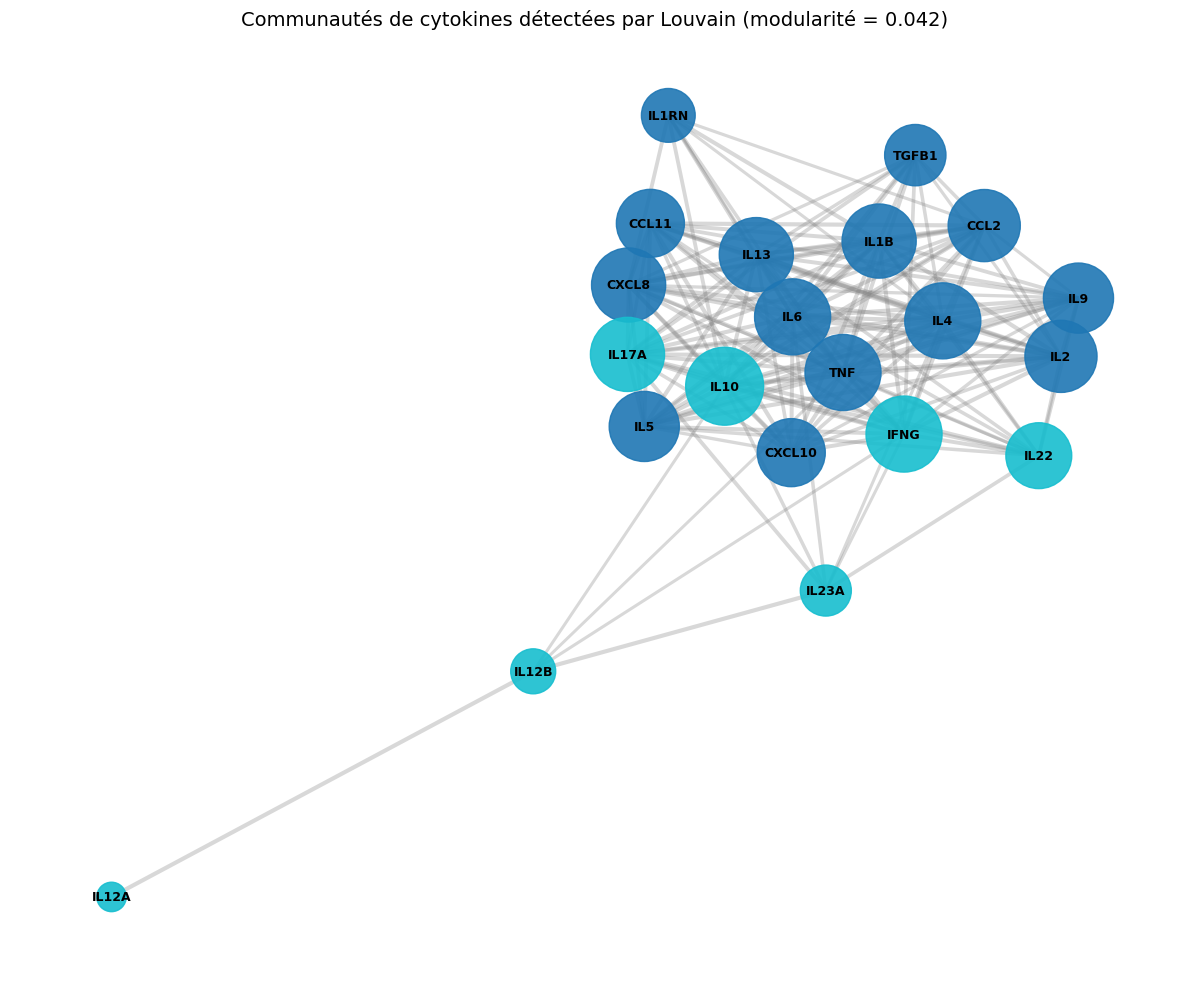

In [5]:
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42, k=0.6)

# Une couleur distincte par communauté
n_communities = len(communities)
palette = cm.get_cmap("tab10", n_communities)
node_colors = [palette(node_to_community[node]) for node in G.nodes()]

degrees = dict(G.degree())
node_sizes = [degrees[node] * 150 + 300 for node in G.nodes()]
edge_weights = [G[u][v]["score"] * 3 for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=edge_weights, alpha=0.3, edge_color="gray")
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")

plt.title(f"Communautés de cytokines détectées par Louvain (modularité = {modularity:.3f})", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.savefig("../data/processed/network_communities.png", dpi=200)
plt.show()

## 5. Interprétation biologique de chaque communauté

Pour chaque communauté détectée, on affiche les fonctions biologiques (UniProt) de ses membres,
afin de voir si elle correspond à une famille fonctionnelle connue (Th1, Th2, Th17, régulatrice, chimiokine...).

In [6]:
for community_id in sorted(community_df["community_id"].unique()):
    members = community_df[community_df["community_id"] == community_id]["cytokine"].tolist()
    print(f"\n{'='*60}")
    print(f"COMMUNAUTÉ {community_id} — {len(members)} cytokines : {members}")
    print("="*60)

    subset = annotations_df[annotations_df["gene_name"].isin(members)]
    for _, row in subset.iterrows():
        func = row["function"]
        func_short = func[:180] + "..." if isinstance(func, str) and len(func) > 180 else func
        print(f"\n  {row['gene_name']} : {func_short}")


COMMUNAUTÉ 0 — 14 cytokines : ['IL6', 'IL4', 'TNF', 'IL1B', 'IL13', 'CXCL8', 'CCL2', 'IL2', 'IL5', 'IL9', 'CCL11', 'CXCL10', 'TGFB1', 'IL1RN']

  IL1B : Potent pro-inflammatory cytokine (PubMed:10653850, PubMed:12794819, PubMed:28331908, PubMed:3920526). Initially discovered as the major endogenous pyrogen, induces prostaglandin sy...

  IL6 : Cytokine with a wide variety of biological functions in immunity, tissue regeneration, and metabolism. Binds to IL6R, then the complex associates to the signaling subunit IL6ST/gp1...

  TNF : Cytokine that binds to TNFRSF1A/TNFR1 and TNFRSF1B/TNFBR. It is mainly secreted by macrophages and can induce cell death of certain tumor cell lines. It is potent pyrogen causing f...

  CXCL8 : Chemotactic factor that mediates inflammatory response by attracting neutrophils, basophils, and T-cells to clear pathogens and protect the host from infection (PubMed:18692776, Pu...

  TGFB1 : Transforming growth factor beta-1 proprotein: Precursor of the Latency

## 6. Enrichissement fonctionnel global (pour référence)

Ce tableau montre les fonctions biologiques les plus significativement associées à l'ensemble
des 21 cytokines (calculé par STRING). On l'utilise pour vérifier que le thème "inflammation"
ressort bien statistiquement, et pour enrichir l'interprétation des communautés ci-dessus.

In [7]:
enrichment_df = pd.read_csv("../data/raw/string_enrichment.csv")

# On trie par p-value/fdr croissante (les résultats les plus significatifs en premier)
fdr_col = "fdr" if "fdr" in enrichment_df.columns else enrichment_df.columns[-1]
top_enrichment = enrichment_df.sort_values(fdr_col).head(15)
top_enrichment[["category", "description", "number_of_genes", fdr_col]]

,category,description,number_of_genes,fdr
990,WikiPathways,Overview of proinflammatory and profibrotic me...,21,3.690000e-43
879,PMID,(2018) Restoring Inflammatory Mediator Balance...,18,6.030000e-39
878,PMID,(2018) Oral sampling methods are associated wi...,18,6.030000e-39
545,Function,Cytokine activity,21,4.720000e-37
882,PMID,(2017) Cytokine and Chemokines Alterations in ...,17,6.200000e-37
880,PMID,(2023) Host immunity and HBV S gene mutation i...,18,6.200000e-37
881,PMID,"(2020) Computational Derivation of Core, Dynam...",17,6.200000e-37
883,PMID,"(2019) Clinical, microbiologic, and immunologi...",17,7.520000e-37
884,PMID,(2017) Th1Th17-Related Cytokines and Chemokine...,17,9.870000e-37
885,PMID,(2019) Cytokines: Key Determinants of Resistan...,18,1.120000e-36


## 7. Tableau de synthèse final (à inclure dans le README)

In [8]:
print("SYNTHÈSE DU PROJET")
print("="*50)
print(f"Nombre de cytokines analysées : {G.number_of_nodes()}")
print(f"Nombre d'interactions (seuil confiance >= 0.7) : {G.number_of_edges()}")
print(f"Densité du réseau : {nx.density(G):.3f}")
print(f"Nombre de communautés détectées : {len(communities)}")
print(f"Score de modularité : {modularity:.3f}")
print(f"Cytokine la plus centrale (degree) : {centrality_df.sort_values('degree_centrality', ascending=False).iloc[0]['cytokine']}")
print(f"Cytokine la plus 'pont' (betweenness) : {centrality_df.sort_values('betweenness_centrality', ascending=False).iloc[0]['cytokine']}")

SYNTHÈSE DU PROJET
Nombre de cytokines analysées : 21
Nombre d'interactions (seuil confiance >= 0.7) : 147
Densité du réseau : 0.700
Nombre de communautés détectées : 2
Score de modularité : 0.042
Cytokine la plus centrale (degree) : IL10
Cytokine la plus 'pont' (betweenness) : TNF


## Résumé de ce notebook

- Détecté les communautés du réseau avec l'algorithme de Louvain (plusieurs résolutions testées)
- Choisi et justifié une résolution finale via le score de modularité
- Visualisé le réseau coloré par communauté (`data/processed/network_communities.png`)
- Interprété chaque communauté à l'aide des fonctions biologiques UniProt
- Vérifié l'enrichissement fonctionnel global du panel de cytokines
- Sauvegardé les assignations finales (`data/processed/community_assignments.csv`)

**Prochaine étape possible (notebook 04, optionnel) :** prédiction de liens manquants
(link prediction) pour suggérer des interactions potentielles non encore documentées dans STRING,
ou enrichissement via UniProtKB pour approfondir l'analyse fonctionnelle de chaque communauté.